In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv("IMDb_Movies_India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [10]:
df.shape

(15509, 10)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


In [12]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [13]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [15]:
df.dropna(subset=['Rating'], inplace=True)

In [16]:
df['Genre'].fillna("Unknown", inplace=True)
df['Director'].fillna("Unknown", inplace=True)
df['Actor 1'].fillna("Unknown", inplace=True)
df['Actor 2'].fillna("Unknown", inplace=True)
df['Actor 3'].fillna("Unknown", inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\3847573832.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Genre'].fillna("Unknown", inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\3847573832.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using 

1          Arvind Jangid
3        Siddhant Kapoor
5          Shammi Kapoor
6         Yashpal Sharma
8           Kiran Bhatia
              ...       
15501            Govinda
15503        Rajinikanth
15504      Suparna Anand
15505        Aruna Irani
15508        Arjun Sarja
Name: Actor 3, Length: 7919, dtype: str

In [26]:
df['Votes'].fillna(0, inplace=True)
df['Duration'].fillna(df['Duration'].median(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\1788176826.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Votes'].fillna(0, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\1788176826.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inpla

1        109.0
3        110.0
5        147.0
6        142.0
8         82.0
         ...  
15501    134.0
15503    125.0
15504    134.0
15505    129.0
15508    130.0
Name: Duration, Length: 7919, dtype: float64

In [27]:
df['Year'] = df['Year'].str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'])
df['Year'].fillna(df['Year'].median(), inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\3479907492.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d{4})')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\3479907492.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/sta

1        2019
3        2019
5        1997
6        2005
8        2012
         ... 
15501    1992
15503    1989
15504    1988
15505    1999
15508    1998
Name: Year, Length: 7919, dtype: int64

In [28]:
df['Duration'] = df['Duration'].astype(str)
df['Duration'] = df['Duration'].str.replace(" min","")
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'].fillna(df['Duration'].median(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\4085609233.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Duration'].fillna(df['Duration'].median(), inplace=True)


1        109.0
3        110.0
5        147.0
6        142.0
8         82.0
         ...  
15501    134.0
15503    125.0
15504    134.0
15505    129.0
15508    130.0
Name: Duration, Length: 7919, dtype: float64

In [29]:
df['Votes'] = df['Votes'].astype(str)
df['Votes'] = df['Votes'].str.replace(",","")
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes'].fillna(0, inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16192\4263218311.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Votes'].fillna(0, inplace=True)


1           8
3          35
5         827
6        1086
8         326
         ... 
15501     135
15503      44
15504      11
15505     655
15508      20
Name: Votes, Length: 7919, dtype: int64

In [30]:
encoder = LabelEncoder()
categorical_columns = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [31]:
df.drop('Name', axis=1, inplace=True)

In [32]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 0.8248781565656566
Mean Squared Error: 1.1904827455808078
Root Mean Squared Error: 1.0910924551021366
R2 Score: 0.35966121226588743


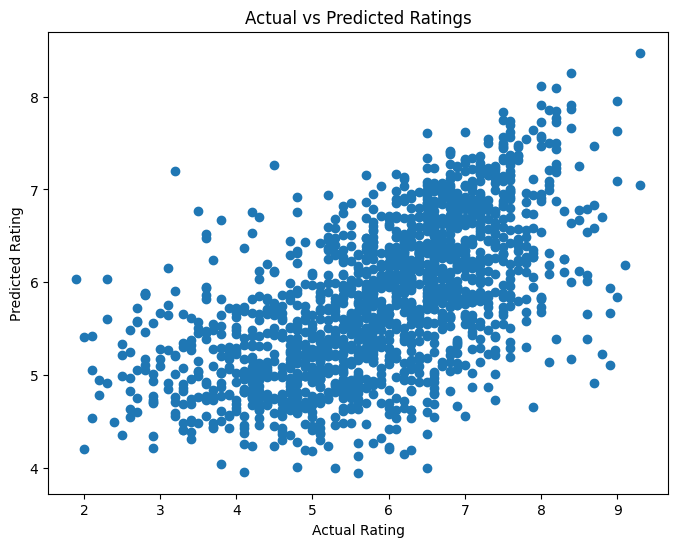

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

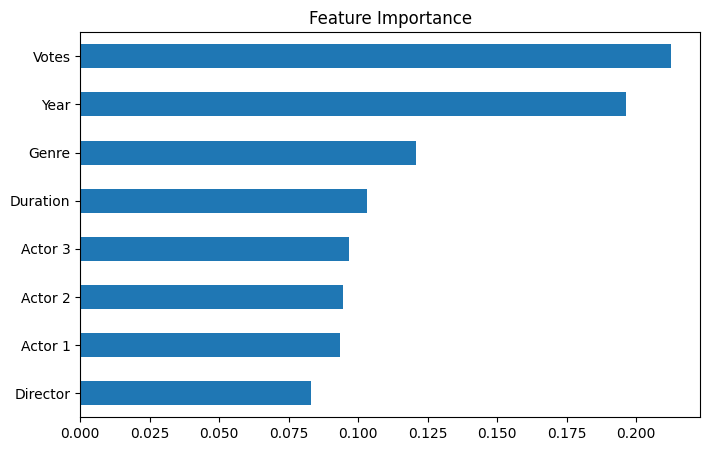

In [38]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()